In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Only using the 'single' task files, per project scope
splits = {
    "train": pd.read_csv("../data/raw/cjpe_dataset_single_train.csv"),
    "dev": pd.read_csv("../data/raw/cjpe_dataset_single_dev.csv"),
    "test": pd.read_csv(
        "../data/raw/cjpe_dataset_test.csv"
    ),  # confirm this is single's test split
}

In [7]:
for name, df in splits.items():
    print(f"{name}: {df.shape[0]} rows, columns = {list(df.columns)}")

train: 5082 rows, columns = ['id', 'text', 'label', 'expert_1', 'expert_2', 'expert_3', 'expert_4', 'expert_5']
dev: 2511 rows, columns = ['id', 'text', 'label', 'expert_1', 'expert_2', 'expert_3', 'expert_4', 'expert_5']
test: 1517 rows, columns = ['id', 'text', 'label', 'expert_1', 'expert_2', 'expert_3', 'expert_4', 'expert_5']


In [8]:
for name, df in splits.items():
    df["word_count"] = df["text"].str.split().str.len()
    print(f"--- {name} ---")
    print(df["word_count"].describe())

--- train ---
count     5082.000000
mean      4011.665289
std       4440.477728
min        147.000000
25%       1972.000000
50%       2982.000000
75%       4589.750000
max      87530.000000
Name: word_count, dtype: float64
--- dev ---
count     2511.000000
mean      3811.512943
std       3446.507448
min         73.000000
25%       1840.500000
50%       2909.000000
75%       4576.500000
max      42198.000000
Name: word_count, dtype: float64
--- test ---
count     1517.000000
mean      3850.203691
std       3476.272004
min         73.000000
25%       1871.000000
50%       2940.000000
75%       4609.000000
max      40487.000000
Name: word_count, dtype: float64


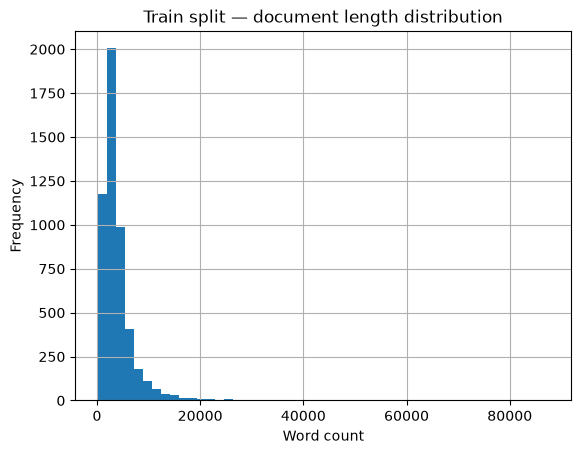

In [9]:
splits["train"]["word_count"].hist(bins=50)
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.title("Train split — document length distribution")
plt.show()

In [10]:
for name, df in splits.items():
    n_null = df["text"].isna().sum()
    n_empty = (df["text"].str.strip() == "").sum()
    print(f"{name}: {n_null} nulls, {n_empty} empty strings")

train: 0 nulls, 0 empty strings
dev: 0 nulls, 0 empty strings
test: 0 nulls, 0 empty strings


In [11]:
for name, df in splits.items():
    n_dupes = df["text"].duplicated().sum()
    print(f"{name}: {n_dupes} duplicate texts")

train: 5 duplicate texts
dev: 0 duplicate texts
test: 0 duplicate texts


In [12]:
sample = splits["train"].sample(5, random_state=42)
for i, row in sample.iterrows():
    print("=" * 80)
    print(row["text"][:2000])

ORIGINAL JURISDICTION Writ Petitions Nos. 1135-1155, 1544-1758, 1759-1949, 1952-1991, 1993-2199, 2216-2220, 2274- 2325 of 1977, 592-607, 849-862 and 1898-1908/78 and 1577- 1605/78. And Writ Petitions Nos. 955 and 966/77. And Writ Petitions Nos. 1222/77 and 4-176 and 2359/78 And Writ Petitions Nos. 967, 1128/77, 314-591, 901-950, 1870-1887,2240-2294, 2367, 2390/78, 3063-3081/78, 1223-1526/ 77, 177-313, 871-900, 2319, 2358 2326-2430/77, 1807-1869, 1239-1312, 1584-1592, 1737-1749, 2296-2311, 2312-2318, 2392- 2472, 2937-2951, 3380-3464/78,- 609-821, 979-1237, 1543- 1583, 1956-2111, 2810-2936/78, 2986-2998/78, 2953-2968/78 2472A-2472B of 1978. And Writ Petitions Nos. 823,3514-3574,824-826,975, 1617- 1627, 1628-1725, 1915-1942/78, 2366, 2610, 3088, 3576, 1313- 1542, 2112-2203, 3131-3340, 1760-1806/78, 2231-2234, 2235- 2236, 2237-2238, 2475, 2476, 2975-2985 of 1978, 3465. 3466- 3513/78, 3622-3641/78,3766, 3801 3786-3788/78 K. Ganguli for the Petitioners in W.P. Nos. 1135- 1155, 1544-1758, 227

In [ ]:
# use this to try one pandas function at a time on a small slice, e.g.:
# splits["train"]["text"].head(3).str.split()